## Import packages

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import spearmanr
import os
import glob
import json
from textwrap import fill

## Load all JSON files

In [45]:
rows = []

for filepath in sorted(glob.glob("outputs/llm_raw/iteration_*.json")):
    filename = os.path.basename(filepath)
    iteration = int(filename.split("_")[1].split(".")[0])  # e.g. iteration_03.json -> 3

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    for item in data:
        irony = item.get("irony", {})

        rows.append({
            "iteration": iteration,
            "comment_id": item["id"],
            "thread": item["thread_title"],
            "comment": item["comment"],
            "irony_score": int(irony.get("irony_score")),
            "confidence_score": int(irony.get("confidence_score")),
            "justification": irony.get("justification"),
            "irony_markers": irony.get("irony_markers", [])
        })

llm_long_df = pd.DataFrame(rows)
llm_long_df.head()

,iteration,comment_id,thread,comment,irony_score,confidence_score,justification,irony_markers
0,1,1,Mehrheit sieht ältere im Vorteil – nicht einma...,Solange alle ihre Tiefkühlpizza und RTL haben ...,4,4,Die wörtliche Behauptung 'Solange alle ihre Ti...,"[sarcasm, critiques media/consumerism, hyperbo..."
1,1,2,Mehrheit sieht ältere im Vorteil – nicht einma...,Ich bin schockiert.,1,4,The comment 'Ich bin schockiert.' is a direct ...,"[literal expression of emotion, no explicit ir..."
2,1,3,Mehrheit sieht ältere im Vorteil – nicht einma...,"Würden sich die babyboomer zu Tode arbeiten, b...",4,4,"The comment uses a hyperbolic, sarcastic state...","[sarcasm, hyperbole, ageism]"
3,1,4,Mehrheit sieht ältere im Vorteil – nicht einma...,Auf den Schreck erstmal eine Rentenerhöhung.,4,4,The comment leverages the idiom 'Auf den Schre...,"[idiom: Auf den Schreck, sarcastic/political c..."
4,1,5,Mehrheit sieht ältere im Vorteil – nicht einma...,Finde den Generationen-Vertrag an sich schon d...,1,4,The comment expresses a literal opinion that t...,[no irony markers detected; literal stance]


In [46]:
llm_long_df.shape

(540, 8)

## Aggregate mean, std and var scores

In [47]:
llm_comment_stats_df = (
    llm_long_df
    .groupby(["comment_id", "thread", "comment"], as_index=False)
    .agg(
        mean_irony=("irony_score", "mean"),
        var_irony=("irony_score", "var"),
        std_irony=("irony_score", "std"),
        mean_confidence=("confidence_score", "mean"),
        var_confidence=("confidence_score", "var"),
        std_confidence=("confidence_score", "std"),
    )
    .sort_values("comment_id")
    .reset_index(drop=True)
)

llm_comment_stats_df.head()

,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
0,1,Mehrheit sieht ältere im Vorteil – nicht einma...,Solange alle ihre Tiefkühlpizza und RTL haben ...,4.000000,0.000000,0.000000,4.000000,0.000000,0.000000
1,2,Mehrheit sieht ältere im Vorteil – nicht einma...,Ich bin schockiert.,1.000000,0.000000,0.000000,4.222222,0.194444,0.440959
2,3,Mehrheit sieht ältere im Vorteil – nicht einma...,"Würden sich die babyboomer zu Tode arbeiten, b...",4.444444,0.277778,0.527046,4.000000,0.000000,0.000000
3,4,Mehrheit sieht ältere im Vorteil – nicht einma...,Auf den Schreck erstmal eine Rentenerhöhung.,3.888889,0.111111,0.333333,4.000000,0.000000,0.000000
4,5,Mehrheit sieht ältere im Vorteil – nicht einma...,Finde den Generationen-Vertrag an sich schon d...,1.000000,0.000000,0.000000,4.111111,0.111111,0.333333


In [48]:
print(llm_comment_stats_df.shape)
print(llm_comment_stats_df.columns)

(60, 9)
Index(['comment_id', 'thread', 'comment', 'mean_irony', 'var_irony',
       'std_irony', 'mean_confidence', 'var_confidence', 'std_confidence'],
      dtype='str')


In [49]:
display(llm_comment_stats_df[llm_comment_stats_df["comment_id"] == 33])

,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
32,33,VW gerettet! Konzern feuert alle Arbeiter und ...,"Unironisch könnte man viele Konzerne retten, w...",3.444444,2.027778,1.424001,4.111111,0.111111,0.333333


### Save to CSV

In [50]:
llm_comment_stats_df.to_csv(
    "outputs/clean/llm_comment_stats.csv",
    index=False
)

## Visualisations

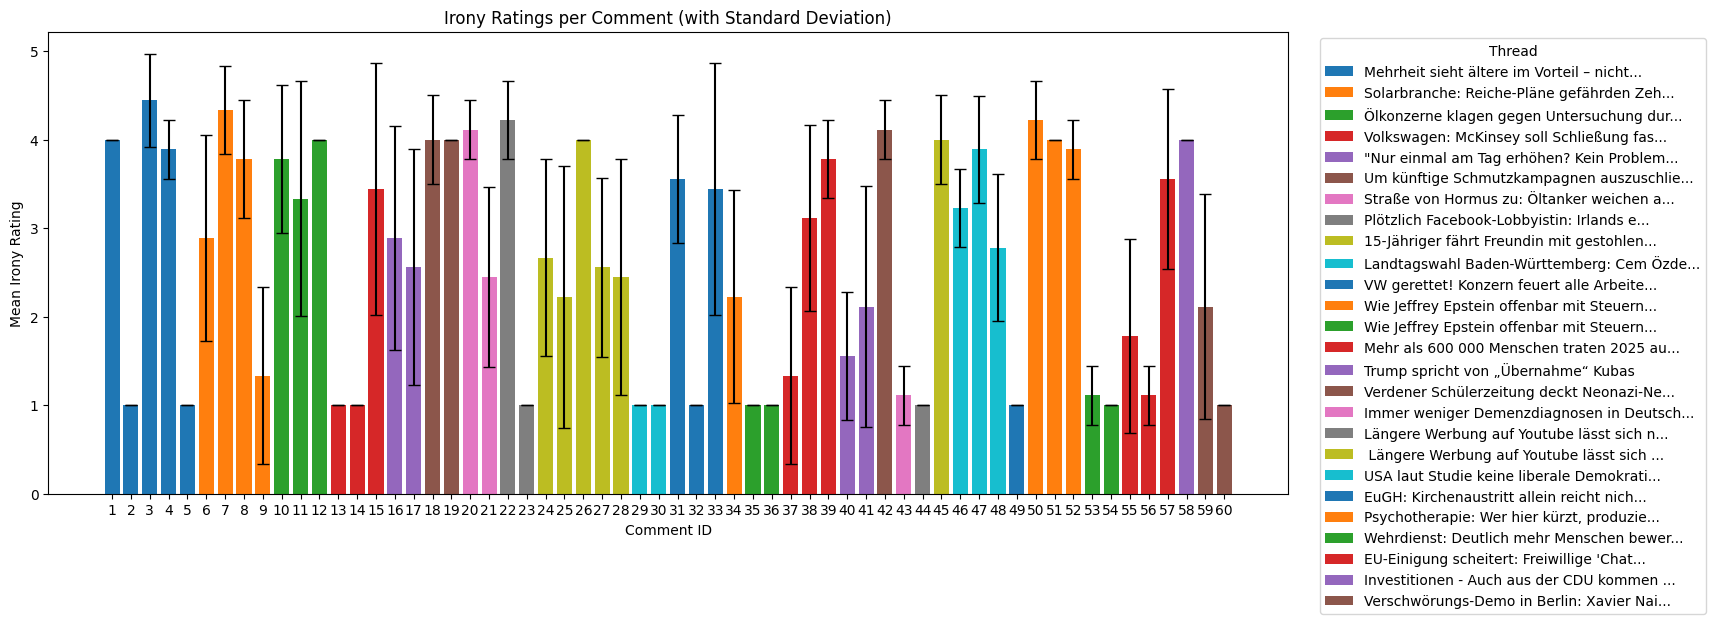

In [51]:
# Create numeric x positions
x = range(len(llm_comment_stats_df))

# Use simple IDs for x-axis
labels = llm_comment_stats_df["comment_id"]

# Assign colors per thread
threads = llm_comment_stats_df["thread"].unique()
cmap = plt.get_cmap("tab10")
thread_colors = {thread: cmap(i % 10) for i, thread in enumerate(threads)}

colors = llm_comment_stats_df["thread"].map(thread_colors)

plt.figure(figsize=(16, 6))

# Bar plot with error bars (standard deviation)
plt.bar(
    x,
    llm_comment_stats_df["mean_irony"],
    yerr=llm_comment_stats_df["std_irony"],
    capsize=4,
    color=colors
)

# Clean x-axis
plt.xticks(x, labels, rotation=0)
plt.xlabel("Comment ID")
plt.ylabel("Mean Irony Rating")
plt.title("Irony Ratings per Comment (with Standard Deviation)")

# Legend for threads
legend_elements = [
    Patch(facecolor=thread_colors[t], label=t[:40] + "..." if len(t) > 40 else t)
    for t in threads
]

plt.legend(
    handles=legend_elements,
    title="Thread",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig("outputs/figures/llm/irony_per_comment.png", dpi=300, bbox_inches="tight")

plt.show()

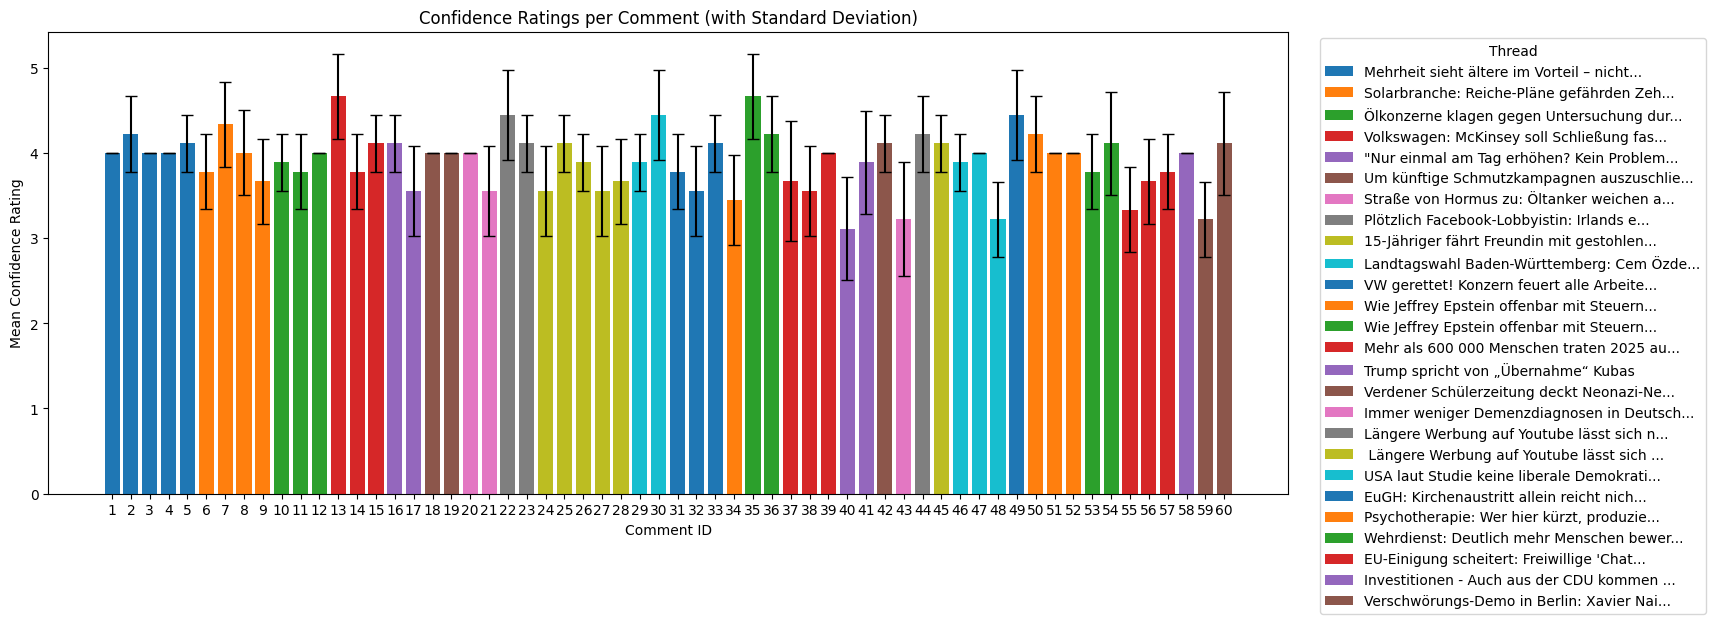

In [52]:
# Create numeric x positions
x = range(len(llm_comment_stats_df))

# Use simple IDs for x-axis
labels = llm_comment_stats_df["comment_id"]

# Assign colors per thread
threads = llm_comment_stats_df["thread"].unique()
cmap = plt.get_cmap("tab10")
thread_colors = {thread: cmap(i % 10) for i, thread in enumerate(threads)}

colors = llm_comment_stats_df["thread"].map(thread_colors)

plt.figure(figsize=(16, 6))

# Bar plot with error bars (standard deviation)
plt.bar(
    x,
    llm_comment_stats_df["mean_confidence"],
    yerr=llm_comment_stats_df["std_confidence"],
    capsize=4,
    color=colors
)

# Clean x-axis
plt.xticks(x, labels, rotation=0)
plt.xlabel("Comment ID")
plt.ylabel("Mean Confidence Rating")
plt.title("Confidence Ratings per Comment (with Standard Deviation)")

# Legend for threads
legend_elements = [
    Patch(facecolor=thread_colors[t], label=t[:40] + "..." if len(t) > 40 else t)
    for t in threads
]

plt.legend(
    handles=legend_elements,
    title="Thread",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.savefig("outputs/figures/llm/confidence_per_comment.png", dpi=300, bbox_inches="tight")
plt.show()

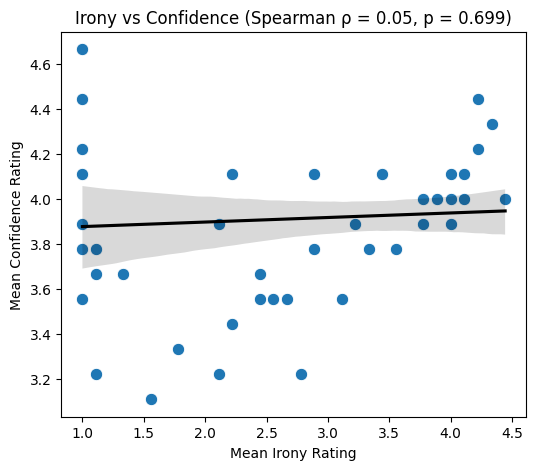

In [53]:
# Compute correlation (just to show it in the plot)
# rho: strength of correlation
# p: significance of the correlation
rho, p = spearmanr(
    llm_comment_stats_df["mean_irony"],
    llm_comment_stats_df["mean_confidence"]
)

plt.figure(figsize=(6, 5))

# Scatter plot
sns.scatterplot(
    data=llm_comment_stats_df,
    x="mean_irony",
    y="mean_confidence",
    s=80
)

# Regression line
sns.regplot(
    data=llm_comment_stats_df,
    x="mean_irony",
    y="mean_confidence",
    scatter=False,
    color="black"
)

# Labels
plt.xlabel("Mean Irony Rating")
plt.ylabel("Mean Confidence Rating")
plt.title(f"Irony vs Confidence (Spearman ρ = {rho:.2f}, p = {p:.3f})")

plt.savefig("outputs/figures/llm/irony_vs_confidence.png", dpi=300, bbox_inches="tight")
plt.show()

In [54]:
comment_25 = llm_long_df[llm_long_df.comment_id == 25]
comment_33 = llm_long_df[llm_long_df.comment_id == 33]

x = [1, 2, 3, 4, 5]

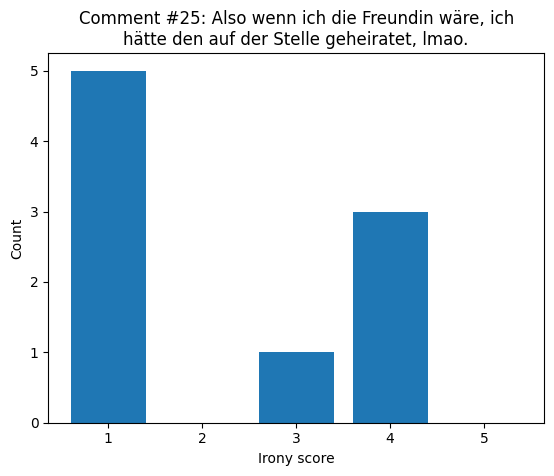

In [55]:
comment_25_title = llm_long_df.loc[llm_long_df.comment_id == 25, "comment"].iloc[0]
wrapped_title = fill(f"Comment #25: {comment_25_title}", width=50)

y = (
    comment_25["irony_score"]
    .value_counts()
    .reindex(x, fill_value=0)
    .to_list()
)

plt.bar(x, y)
plt.xlabel("Irony score")
plt.ylabel("Count")
plt.title(wrapped_title)

plt.savefig("outputs/figures/llm/irony_scores_comment_25.png", dpi=300, bbox_inches="tight")
plt.show()

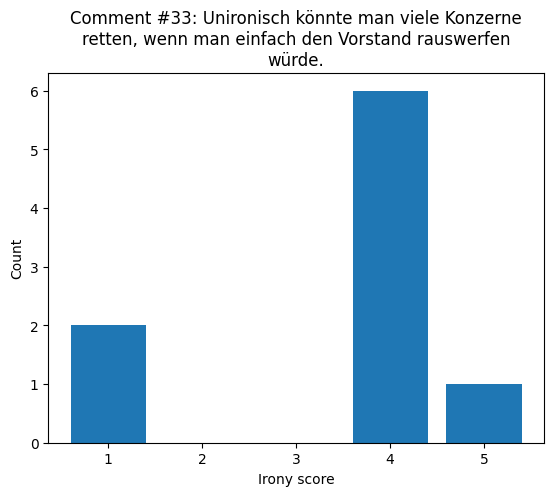

In [56]:
comment_33_title = llm_long_df.loc[llm_long_df.comment_id == 33, "comment"].iloc[0]
wrapped_title = fill(f"Comment #33: {comment_33_title}", width=50)


y = (
    comment_33["irony_score"]
    .value_counts()
    .reindex(x, fill_value=0)
    .to_list()
)

plt.bar(x, y)
plt.xlabel("Irony score")
plt.ylabel("Count")
plt.title(wrapped_title)
plt.savefig("outputs/figures/llm/irony_scores_comment_33.png", dpi=300, bbox_inches="tight")
plt.show()

## Measurements

### Cronbach's Alpha
#### Reliability coefficient and a measure of the internal consistency of our survey
**Irony alpha**: Are all comments consistenly measuring irony?

**Confidence alpha**: Are LLM iterations consistent in how confident the LLM is?

In [57]:
def build_reliability_matrix(score_column):
    comment_meta = (
        llm_long_df[["comment_id", "thread", "comment"]]
        .drop_duplicates()
        .sort_values("comment_id")
        .assign(
            comment_label=lambda df: df.apply(
                lambda row: (
                    f"KOMMENTAR #{row['comment_id']}\n\n"
                    f"THREAD: {row['thread']}\n\n"
                    f"KOMMENTAR: {row['comment']}\n\n"
                    "Wie ironisch ist dieser Kommentar?"
                ),
                axis=1,
            )
        )
    )

    reliability_df = llm_long_df.merge(
        comment_meta[["comment_id", "comment_label"]],
        on="comment_id",
        how="left",
        validate="many_to_one",
    )

    matrix = reliability_df.pivot(
        index="iteration",
        columns="comment_label",
        values=score_column,
    ).sort_index()

    return matrix.reindex(columns=comment_meta["comment_label"])


irony = build_reliability_matrix("irony_score")
confidence = build_reliability_matrix("confidence_score")


def cronbach_alpha(df):
    clean_df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
    k = clean_df.shape[1]

    if k < 2:
        raise ValueError("Cronbach's alpha requires at least two items.")

    variance_sum = clean_df.var(axis=0, ddof=1).sum()
    total_var = clean_df.sum(axis=1).var(ddof=1)

    if total_var == 0:
        return float("nan")

    return (k / (k - 1)) * (1 - (variance_sum / total_var))

In [58]:
alpha_irony = cronbach_alpha(irony)
alpha_confidence = cronbach_alpha(confidence)

In [59]:
alpha_irony

np.float64(0.3954802259887005)

In [60]:
alpha_confidence

np.float64(0.33898305084745756)

### Krippendorff's Alpha
#### How much do annotators agree with each other, beyond chance?
In our case it answers "Do LLM iterations assign similar irony ratings to the same comments?"

In [61]:
irony.values.shape

(9, 60)

In [62]:
irony

comment_label,KOMMENTAR #1\n\nTHREAD: Mehrheit sieht ältere im Vorteil – nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Solange alle ihre Tiefkühlpizza und RTL haben ist doch alles super!\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #2\n\nTHREAD: Mehrheit sieht ältere im Vorteil – nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Ich bin schockiert.\n\nWie ironisch ist dieser Kommentar?,"KOMMENTAR #3\n\nTHREAD: Mehrheit sieht ältere im Vorteil – nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Würden sich die babyboomer zu Tode arbeiten, bräuchte man ihnen keine Rente mehr zahlen\n\nWie ironisch ist dieser Kommentar?",KOMMENTAR #4\n\nTHREAD: Mehrheit sieht ältere im Vorteil – nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Auf den Schreck erstmal eine Rentenerhöhung.\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #5\n\nTHREAD: Mehrheit sieht ältere im Vorteil – nicht einmal ein Drittel der jungen glaubt an faire Rente\n\nKOMMENTAR: Finde den Generationen-Vertrag an sich schon dämlich. Will meine eigenen Rente auffüllen und nicht die von anderen.\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #6\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: ist ja nicht so als wären es jobs in der automobilindustrie also warum die aufregung\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #7\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: Leute alles gut. Laut der Eu Präsidentin kriegen wir bald eh alle kleine Mini Akws und dann jeder seinen eigenen Atompilz im Keller\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #8\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: Die Öl&Gas Lobby macht halt n guten Job und die Reiche ist dankbares Opfer!\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #9\n\nTHREAD: Solarbranche: Reiche-Pläne gefährden Zehntausende Jobs\n\nKOMMENTAR: Vergeht denn kein Tag wo dieser Roboter keine Dummheit macht\n\nWie ironisch ist dieser Kommentar?,"KOMMENTAR #10\n\nTHREAD: Ölkonzerne klagen gegen Untersuchung durch Bundeskartellamt\n\nKOMMENTAR: Wer Probleme mit niedrigem Blutdruck hat, sollte den Artikel lesen. Dann pumpt es wieder ordentlich.\n\nWie ironisch ist dieser Kommentar?",...,"KOMMENTAR #51\n\nTHREAD: Psychotherapie: Wer hier kürzt, produziert mehr Krankheit und Leid\n\nKOMMENTAR: Ja, aber ihr müsst das einfach durch die Wirtschaftskompetenzbrille der Union betrachten. Wenn man das jetzt kürzt, gibts auch weniger Diagnosen, die das Jobcenter anzweifeln muss. Was wir dadurch an Verwaltungskosten sparen werden - so große Zahlen gibts garnicht .....\n\nWie ironisch ist dieser Kommentar?","KOMMENTAR #52\n\nTHREAD: Psychotherapie: Wer hier kürzt, produziert mehr Krankheit und Leid\n\nKOMMENTAR: Sehen Sie demnächst in diesem Theater: ""Oh nein, wo kommen denn die ganzen Obdachlosen her?""\n\nWie ironisch ist dieser Kommentar?","KOMMENTAR #53\n\nTHREAD: Wehrdienst: Deutlich mehr Menschen bewerben sich bei der Bundeswehr\n\nKOMMENTAR: Wenn der Arbeitsmarkt schwächelt, steigt die Attraktivität von sicheren Arbeitgebern. Ganz normale und nachvollziehbare Entwicklung eigentlich.\n\nWie ironisch ist dieser Kommentar?","KOMMENTAR #54\n\nTHREAD: Wehrdienst: Deutlich mehr Menschen bewerben sich bei der Bundeswehr\n\nKOMMENTAR: Also sollten wir schleunigst den Wehrdienst wieder einführen, weil freiwilligkeit offensichtlich nicht funktioniert, wenn die Anreize stimmen. Zwang ist der beste weg\n\nWie ironisch ist dieser Kommentar?",KOMMENTAR #55\n\nTHREAD: EU-Einigung scheitert: Freiwillige 'Chatkontrolle' endet\n\nKOMMENTAR: Bis zum nächsten Versuch.\n\nWie ironisch ist dieser Kommentar?,KOMMENTAR #56\n\nTHREAD: EU-Einigung scheitert: Freiwillige 'Chatkontrolle' endet\n\nKOMMENTAR: Für heute?\n\nWie ironisch ist dieser Kommentar?,"KOMMENTAR #57\n\nTHREAD: EU-Einigung scheitert: Freiwillige 'Chatkontrolle' endet\n\nKOMMENTAR: Superheld Spong

In [63]:
krippendorff.alpha(reliability_data=irony.values, level_of_measurement='ordinal')

np.float64(0.7236686926229434)

In [64]:
(irony.std(axis=0) == 0).sum()

np.int64(20)

In [65]:
irony.T.corr()

iteration,1,2,3,4,5,6,7,8,9
iteration,,,,,,,,,
1,1.000000,0.692064,0.746725,0.715438,0.835637,0.784958,0.773574,0.707160,0.784232
2,0.692064,1.000000,0.757782,0.719391,0.757747,0.624045,0.726002,0.693959,0.835621
3,0.746725,0.757782,1.000000,0.772318,0.773647,0.648374,0.746522,0.748556,0.780163
4,0.715438,0.719391,0.772318,1.000000,0.745736,0.595938,0.671851,0.753862,0.685149
5,0.835637,0.757747,0.773647,0.745736,1.000000,0.661703,0.821524,0.770836,0.811920
6,0.784958,0.624045,0.648374,0.595938,0.661703,1.000000,0.604212,0.678291,0.759246
7,0.773574,0.726002,0.746522,0.671851,0.821524,0.604212,1.000000,0.690929,0.715679
8,0.707160,0.693959,0.748556,0.753862,0.770836,0.678291,0.690929,1.000000,0.771739
9,0.784232,0.835621,0.780163,0.685149,0.811920,0.759246,0.715679,0.771739,1.000000


## Find problematic comments

In [66]:
irony.std(axis=0).sort_values(ascending=False)[:3]

comment_label
KOMMENTAR #25\n\nTHREAD: 15-Jähriger fährt Freundin mit gestohlenem Linienbus zur Schule\n\nKOMMENTAR: Also wenn ich die Freundin wäre, ich hätte den auf der Stelle geheiratet, lmao.\n\nWie ironisch ist dieser Kommentar?                             1.481366
KOMMENTAR #33\n\nTHREAD: VW gerettet! Konzern feuert alle Arbeiter und behält nur noch den Vorstand\n\nKOMMENTAR: Unironisch könnte man viele Konzerne retten, wenn man einfach den Vorstand rauswerfen würde.\n\nWie ironisch ist dieser Kommentar?     1.424001
KOMMENTAR #15\n\nTHREAD: Volkswagen: McKinsey soll Schließung fast aller deutschen Werke empfehlen\n\nKOMMENTAR: Was die dann an personalkosten sparen können sich die Manager wieder als Boni auszahlen lassen\n\nWie ironisch ist dieser Kommentar?    1.424001
dtype: float64

In [67]:
display(llm_comment_stats_df[llm_comment_stats_df["comment_id"] == 25])
display(llm_comment_stats_df[llm_comment_stats_df["comment_id"] == 33])
display(llm_comment_stats_df[llm_comment_stats_df["comment_id"] == 15])

,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
24,25,15-Jähriger fährt Freundin mit gestohlenem Lin...,"Also wenn ich die Freundin wäre, ich hätte den...",2.222222,2.194444,1.481366,4.111111,0.111111,0.333333


,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
32,33,VW gerettet! Konzern feuert alle Arbeiter und ...,"Unironisch könnte man viele Konzerne retten, w...",3.444444,2.027778,1.424001,4.111111,0.111111,0.333333


,comment_id,thread,comment,mean_irony,var_irony,std_irony,mean_confidence,var_confidence,std_confidence
14,15,Volkswagen: McKinsey soll Schließung fast alle...,Was die dann an personalkosten sparen können s...,3.444444,2.027778,1.424001,4.111111,0.111111,0.333333


In [68]:
best_example = llm_comment_stats_df.sort_values("std_irony").iloc[0]
best_example

comment_id                                                         1
thread             Mehrheit sieht ältere im Vorteil – nicht einma...
comment            Solange alle ihre Tiefkühlpizza und RTL haben ...
mean_irony                                                       4.0
var_irony                                                        0.0
std_irony                                                        0.0
mean_confidence                                                  4.0
var_confidence                                                   0.0
std_confidence                                                   0.0
Name: 0, dtype: object

In [69]:
print(best_example["thread"])
print(best_example["comment"])

Mehrheit sieht ältere im Vorteil – nicht einmal ein Drittel der jungen glaubt an faire Rente
Solange alle ihre Tiefkühlpizza und RTL haben ist doch alles super!


In [70]:
worst_example = llm_comment_stats_df.sort_values("std_irony", ascending=False).iloc[0]
worst_example

comment_id                                                        25
thread             15-Jähriger fährt Freundin mit gestohlenem Lin...
comment            Also wenn ich die Freundin wäre, ich hätte den...
mean_irony                                                  2.222222
var_irony                                                   2.194444
std_irony                                                   1.481366
mean_confidence                                             4.111111
var_confidence                                              0.111111
std_confidence                                              0.333333
Name: 24, dtype: object

In [71]:
print(worst_example["thread"])
print(worst_example["comment"])

15-Jähriger fährt Freundin mit gestohlenem Linienbus zur Schule
Also wenn ich die Freundin wäre, ich hätte den auf der Stelle geheiratet, lmao.


In [72]:
col_idx = best_example.name   # original row index in comment_stats_df

irony_ratings = irony.iloc[:, col_idx]
confidence_ratings = confidence.iloc[:, col_idx]

print("Irony:", irony_ratings.to_list())
print("Confidence:", confidence_ratings.to_list())

Irony: [4, 4, 4, 4, 4, 4, 4, 4, 4]
Confidence: [4, 4, 4, 4, 4, 4, 4, 4, 4]


In [73]:
col_idx = worst_example.name

irony_ratings = irony.iloc[:, col_idx]
confidence_ratings = confidence.iloc[:, col_idx]

print("Irony:", irony_ratings.to_list())
print("Confidence:", confidence_ratings.to_list())

Irony: [4, 1, 1, 1, 4, 3, 1, 1, 4]
Confidence: [4, 4, 4, 4, 4, 4, 4, 4, 5]


In [74]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

rows = []

for col_idx in range(irony.shape[1]):
    irony_vals = irony.iloc[:, col_idx]
    confidence_vals = confidence.iloc[:, col_idx]

    rho, p = spearmanr(irony_vals, confidence_vals)

    rows.append({
        "col_idx": col_idx,
        "comment_id": llm_comment_stats_df.iloc[col_idx]["comment_id"],
        "thread": llm_comment_stats_df.iloc[col_idx]["thread"],
        "comment": llm_comment_stats_df.iloc[col_idx]["comment"],
        "std_irony": llm_comment_stats_df.iloc[col_idx]["std_irony"],
        "std_confidence": llm_comment_stats_df.iloc[col_idx]["std_confidence"],
        "rho_comment": rho,
        "p_comment": p,
        "irony_vals": irony_vals.to_list(),
        "confidence_vals": confidence_vals.to_list(),
    })

llm_spearman_examples_df = pd.DataFrame(rows)
llm_spearman_examples_df.head()

/var/folders/1m/bp2n46pj3yd27xcq00_3hj4c0000gn/T/ipykernel_70418/933311819.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(irony_vals, confidence_vals)


,col_idx,comment_id,thread,comment,std_irony,std_confidence,rho_comment,p_comment,irony_vals,confidence_vals
0,0,1,Mehrheit sieht ältere im Vorteil – nicht einma...,Solange alle ihre Tiefkühlpizza und RTL haben ...,0.000000,0.000000,NaN,NaN,"[4, 4, 4, 4, 4, 4, 4, 4, 4]","[4, 4, 4, 4, 4, 4, 4, 4, 4]"
1,1,2,Mehrheit sieht ältere im Vorteil – nicht einma...,Ich bin schockiert.,0.000000,0.440959,NaN,NaN,"[1, 1, 1, 1, 1, 1, 1, 1, 1]","[4, 4, 4, 5, 5, 4, 4, 4, 4]"
2,2,3,Mehrheit sieht ältere im Vorteil – nicht einma...,"Würden sich die babyboomer zu Tode arbeiten, b...",0.527046,0.000000,NaN,NaN,"[4, 4, 4, 5, 5, 4, 5, 5, 4]","[4, 4, 4, 4, 4, 4, 4, 4, 4]"
3,3,4,Mehrheit sieht ältere im Vorteil – nicht einma...,Auf den Schreck erstmal eine Rentenerhöhung.,0.333333,0.000000,NaN,NaN,"[4, 4, 3, 4, 4, 4, 4, 4, 4]","[4, 4, 4, 4, 4, 4, 4, 4, 4]"
4,4,5,Mehrheit sieht ältere im Vorteil – nicht einma...,Finde den Generationen-Vertrag an sich schon d...,0.000000,0.333333,NaN,NaN,"[1, 1, 1, 1, 1, 1, 1, 1, 1]","[4, 4, 4, 4, 4, 4, 5, 4, 4]"


In [75]:
candidates = llm_spearman_examples_df[
    (llm_spearman_examples_df["std_irony"] > 1.0) &
    (llm_spearman_examples_df["std_confidence"] < 0.5)
].copy()

candidates["abs_rho"] = candidates["rho_comment"].abs()

candidates = candidates.sort_values(
    ["abs_rho", "std_irony", "std_confidence"],
    ascending=[True, False, True]
)

candidates[[
    "comment_id", "std_irony", "std_confidence", "rho_comment", "p_comment"
]].head(10)

,comment_id,std_irony,std_confidence,rho_comment,p_comment
58,59,1.269296,0.440959,0.109109,0.779918
10,11,1.322876,0.440959,0.357143,0.345399
27,28,1.333333,0.500000,0.379663,0.313541
56,57,1.013794,0.440959,0.425210,0.253898
5,6,1.166667,0.440959,0.440534,0.235315
24,25,1.481366,0.333333,0.459279,0.213620
15,16,1.269296,0.333333,-0.505181,0.165373
32,33,1.424001,0.333333,-0.572822,0.106932
54,55,1.092906,0.500000,-0.603023,0.085619
14,15,1.424001,0.333333,0.654654,0.055702


In [76]:
best_spearman_example = candidates.iloc[0]
print(best_spearman_example["thread"])
print(best_spearman_example["comment"])

Verschwörungs-Demo in Berlin: Xavier Naidoo singt „Dieser Weg“ – deutlich weniger Teilnehmende als angekündigt
Gab's da auch embryonal gewürzte Currywurst mit Pommes?


In [77]:
print("Comment ID:", best_spearman_example["comment_id"])
print("Thread:", best_spearman_example["thread"])
print("Comment:", best_spearman_example["comment"])
print("Irony:", best_spearman_example["irony_vals"])
print("Confidence:", best_spearman_example["confidence_vals"])
print("rho:", best_spearman_example["rho_comment"])
print("p:", best_spearman_example["p_comment"])

Comment ID: 59
Thread: Verschwörungs-Demo in Berlin: Xavier Naidoo singt „Dieser Weg“ – deutlich weniger Teilnehmende als angekündigt
Comment: Gab's da auch embryonal gewürzte Currywurst mit Pommes?
Irony: [2, 4, 1, 1, 2, 1, 3, 1, 4]
Confidence: [3, 4, 3, 4, 3, 3, 3, 3, 3]
rho: 0.1091089451179962
p: 0.7799183942186222


In [78]:
for col_idx in range(irony.shape[1]):
    iv = irony.iloc[:, col_idx].to_list()
    cv = confidence.iloc[:, col_idx].to_list()
    if iv == [4, 1, 1, 1, 4, 3, 1, 1, 4] and cv == [4, 4, 4, 4, 4, 4, 4, 4, 5]:
        print("Found at col_idx:", col_idx)
        print(llm_comment_stats_df.iloc[col_idx][["comment_id", "thread", "comment"]])

Found at col_idx: 24
comment_id                                                   25
thread        15-Jähriger fährt Freundin mit gestohlenem Lin...
comment       Also wenn ich die Freundin wäre, ich hätte den...
Name: 24, dtype: object


## Compare agreement vs confidence
Do annotators behave consistently / overconfidently?

In [79]:
agreement = irony.std(axis=1)
confidence_mean = confidence.mean(axis=1)

spearmanr(agreement, confidence_mean)

SignificanceResult(statistic=np.float64(0.26891705818112577), pvalue=np.float64(0.484116053135612))